In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Eval train time line

In [3]:
eval_test_time = [1600, 3200, 4800, 6400, 8000]
m_5_1 = np.array([0.1574, 0.2135, 0.2126, 0.2271, 0.2332]) *100
m_5_5 = np.array([0.2485, 0.2967, 0.3145, 0.3040, 0.3173])*100
m_10_1 = np.array([0.1384, 0.1592, 0.1628, 0.1639, 0.1688])*100
m_10_5 = np.array([0.2110, 0.2286, 0.2480, 0.2531, 0.2433])*100

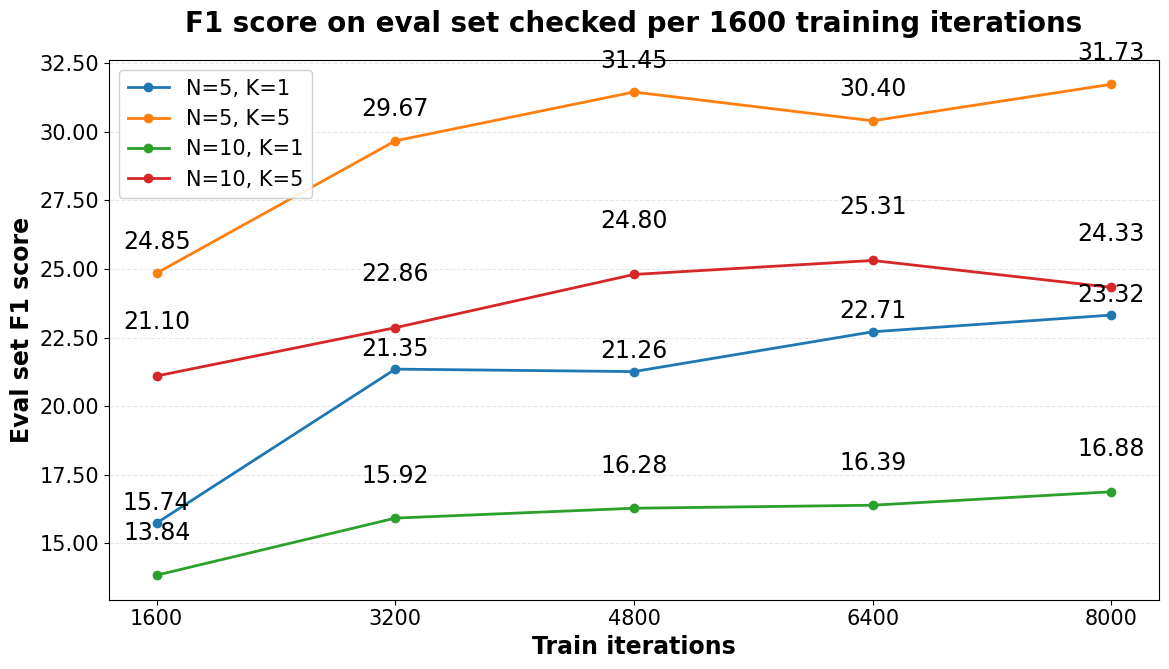

In [4]:
from matplotlib.ticker import FormatStrFormatter

plt.rcParams.update(
    {
        "font.size": 17,
        "axes.titlesize": 20,
        "axes.labelsize": 17,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 15,
    }
)


def label_points(x, y, y_offset_pts=6, ax=None):
    ax = ax or plt.gca()
    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.2f}",
            (xi, yi),
            textcoords="offset points",
            xytext=(0, y_offset_pts),
            ha="center",
            va="bottom",
        )


fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(eval_test_time, m_5_1, marker="o", label="N=5, K=1", linewidth=2)
label_points(eval_test_time, m_5_1, y_offset_pts=6, ax=ax)
ax.plot(eval_test_time, m_5_5, marker="o", label="N=5, K=5", linewidth=2)
label_points(eval_test_time, m_5_5, y_offset_pts=14, ax=ax)
ax.plot(eval_test_time, m_10_1, marker="o", label="N=10, K=1", linewidth=2)
label_points(eval_test_time, m_10_1, y_offset_pts=22, ax=ax)
ax.plot(eval_test_time, m_10_5, marker="o", label="N=10, K=5", linewidth=2)
label_points(eval_test_time, m_10_5, y_offset_pts=30, ax=ax)
ax.set_xticks(eval_test_time)
ax.set_xlabel("Train iterations", fontweight="bold")
ax.set_ylabel("Eval set F1 score", fontweight="bold")
ax.set_title("F1 score on eval set checked per 1600 training iterations", fontweight="bold", pad=20)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

## EDA

In [5]:
df_5_1 = pd.read_csv("metrics/proto-inter-5-1-seed0-llama-lora-inter-5way-1shot.csv")
df_5_5 = pd.read_csv("metrics/proto-inter-5-5-seed0-llama-lora-inter-5way-5shot.csv")
df_10_1 = pd.read_csv("metrics/proto-inter-10-1-seed0-llama-lora-inter-10way-1shot.csv")
df_10_5 = pd.read_csv("metrics/proto-inter-10-5-seed0-llama-lora-inter-10way-5shot.csv")

df_5_1 = df_5_1.select_dtypes(include='number') * 100
df_5_5 = df_5_5.select_dtypes(include='number') * 100
df_10_1 = df_10_1.select_dtypes(include='number') * 100
df_10_5 = df_10_5.select_dtypes(include='number') * 100

In [6]:
ins_df_5_1 = pd.read_csv("ner_results_with_json_proto_format/proto-n5-k1.csv")
ins_df_5_5 = pd.read_csv("ner_results_with_json_proto_format/proto-n5-k5.csv")
ins_df_10_1 = pd.read_csv("ner_results_with_json_proto_format/proto-n10-k1.csv")
ins_df_10_5 = pd.read_csv("ner_results_with_json_proto_format/proto-n10-k5.csv")

ins_df_5_1=ins_df_5_1.select_dtypes(include='number') * 100
ins_df_5_5=ins_df_5_5.select_dtypes(include='number') * 100
ins_df_10_1=ins_df_10_1.select_dtypes(include='number') * 100
ins_df_10_5=ins_df_10_5.select_dtypes(include='number') * 100

In [7]:
ins_df_10_5.round(2).head()

,precision,recall,f1,fp_cnt,fn_cnt,within_error,outer_error,support
0,24.16,12.84,16.77,533200,1153000,0.00,0.00,NaN
1,10.87,2.03,3.43,20500,120400,0.48,0.33,122900.0
2,17.25,8.63,11.50,49400,109100,0.70,0.41,119400.0
3,3.26,2.41,2.77,80100,109300,0.36,0.50,112000.0
4,20.50,11.46,14.70,70200,139800,0.83,0.58,157900.0


In [9]:
run_name = ["N=5, K=1", "N=5, K=5", "N=10, K=1", "N=10, K=5"]
test_f1 = [df_5_1.loc[df_5_1["type"] == "overall", "f1"].item(), df_5_5.loc[df_5_5["type"] == "overall", "f1"].item(), df_10_1.loc[df_10_1["type"] == "overall", "f1"].item(), df_10_5.loc[df_10_5["type"] == "overall", "f1"].item()]
test_precision = [df_5_1.loc[df_5_1["type"] == "overall", "precision"].item(), df_5_5.loc[df_5_5["type"] == "overall", "precision"].item(), df_10_1.loc[df_10_1["type"] == "overall", "precision"].item(), df_10_5.loc[df_10_5["type"] == "overall", "precision"].item()]
test_recall = [df_5_1.loc[df_5_1["type"] == "overall", "recall"].item(), df_5_5.loc[df_5_5["type"] == "overall", "f1"].item(), df_10_1.loc[df_10_1["type"] == "overall", "f1"].item(), df_10_5.loc[df_10_5["type"] == "overall", "f1"].item()]

KeyError: 'type'

In [ ]:
print(test_recall)

[0.3926905131989274, 0.3761861321334072, 0.2340396059907518, 0.3274066717127747]


In [10]:
x = np.arange(len(run_name))
width = 0.2

plt.figure(figsize=(12, 7))
plt.bar(x - 0.25, test_f1, width, label="F1", color="C0", edgecolor="black", linewidth=0.5)
plt.bar(x, test_precision, width, label="Precision", color="C1", edgecolor="black", linewidth=0.5)
plt.bar(x + 0.25, test_recall, width, label="Recall", color="C2", edgecolor="black", linewidth=0.5)

plt.xlabel("Run", fontsize=12, fontweight="bold")
plt.ylabel("Score", fontsize=12, fontweight="bold")
plt.title("Comparison of F1, Precision, and Recall across runs", fontsize=14, fontweight="bold", pad=20)
plt.xticks(x, run_name, rotation=45, ha="right")
plt.ylim(0, max(max(test_f1), max(test_precision), max(test_recall)) * 1.1)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

NameError: name 'test_f1' is not defined

<Figure size 1200x700 with 0 Axes>

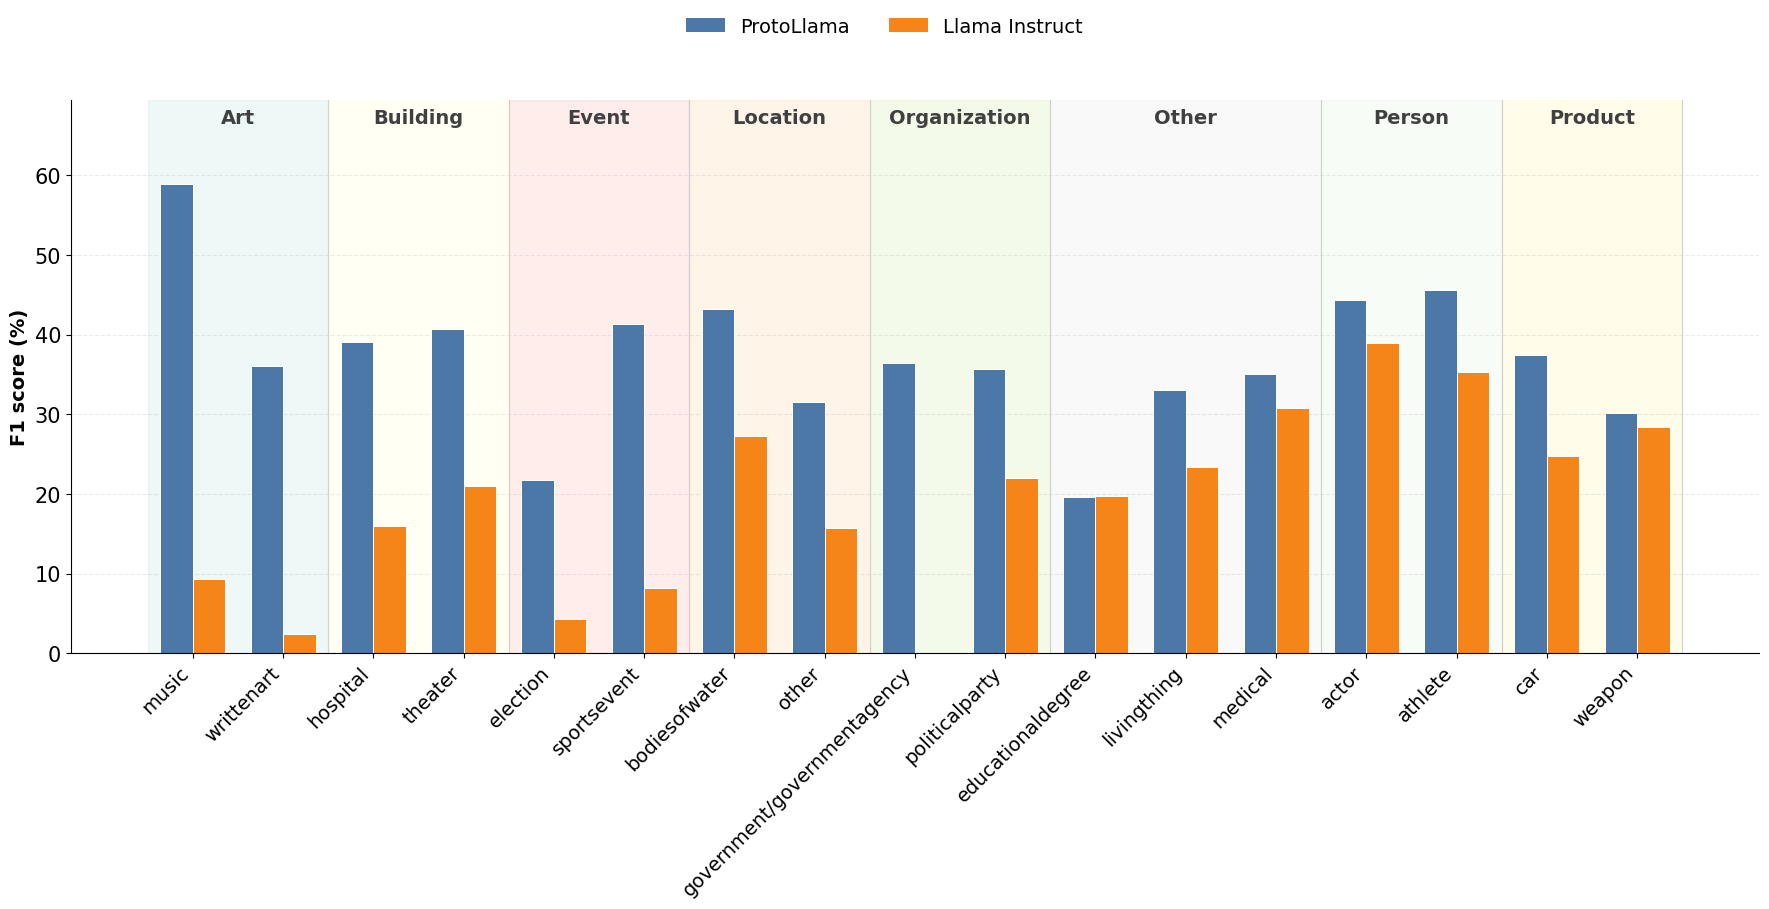

In [11]:
# Compare ProtoLlama and Llama Instruct on 5-way 5-shot fine-grained entity types
from pathlib import Path
from matplotlib.patches import Patch

run_files = {
    "ProtoLlama": "metrics/proto-inter-5-5-seed0-llama-lora-inter-5way-5shot.csv",
    "Llama Instruct": "ner_results_with_json_proto_format/proto-n5-k5.csv",
}


def load_fine_metrics(path, model):
    df = pd.read_csv(path)
    df["type"] = df["type"].astype(str)
    for metric in ["precision", "recall", "f1"]:
        df[metric] = pd.to_numeric(df[metric], errors="coerce") * 100

    fine_df = df[df["type"].str.contains("-", na=False)].copy()
    fine_df[["coarse_type", "fine_type"]] = fine_df["type"].str.split("-", n=1, expand=True)
    fine_df["model"] = model
    return fine_df[["model", "coarse_type", "fine_type", "f1"]]


viz_df = pd.concat(
    [load_fine_metrics(path, model) for model, path in run_files.items()],
    ignore_index=True,
)

# Keep a stable Few-NERD order: coarse category order from the data, then fine category name.
coarse_order = list(dict.fromkeys(viz_df["coarse_type"]))
coarse_rank = {coarse_type: i for i, coarse_type in enumerate(coarse_order)}
category_order = (
    viz_df[["coarse_type", "fine_type"]]
    .drop_duplicates()
    .assign(coarse_rank=lambda x: x["coarse_type"].map(coarse_rank))
    .sort_values(["coarse_rank", "fine_type"])
    .reset_index(drop=True)
)
category_order["category"] = category_order["coarse_type"] + "-" + category_order["fine_type"]
viz_df["category"] = viz_df["coarse_type"] + "-" + viz_df["fine_type"]

model_order = ["ProtoLlama", "Llama Instruct"]
model_colors = {"ProtoLlama": "#4C78A8", "Llama Instruct": "#F58518"}
coarse_colors = dict(zip(coarse_order, plt.cm.Set3(np.linspace(0, 1, len(coarse_order)))))

pivot = (
    viz_df.pivot_table(index="category", columns="model", values="f1", aggfunc="mean")
    .reindex(category_order["category"])
)

fig, ax = plt.subplots(figsize=(18, 10))
x = np.arange(len(category_order))
bar_width = 0.36
ymax = viz_df["f1"].max() * 1.18

for i, model in enumerate(model_order):
    offset = (i - 0.5) * bar_width
    ax.bar(
        x + offset,
        pivot[model],
        width=bar_width,
        color=model_colors[model],
        edgecolor="white",
        linewidth=0.7,
        label=model,
    )

for coarse_type, group in category_order.groupby("coarse_type", sort=False):
    start, end = group.index.min(), group.index.max()
    ax.axvspan(start - 0.5, end + 0.5, color=coarse_colors[coarse_type], alpha=0.14, zorder=0)
    ax.axvline(end + 0.5, color="0.82", linewidth=0.8, zorder=1)
    ax.text(
        (start + end) / 2,
        ymax * 0.985,
        coarse_type.capitalize(),
        ha="center",
        va="top",
        fontsize=14,
        fontweight="bold",
        color="0.25",
    )

ax.set_ylabel("F1 score (%)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(category_order["fine_type"], rotation=45, ha="right", fontsize=14)
ax.set_ylim(0, ymax)
ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

model_handles = [Patch(facecolor=model_colors[model], label=model) for model in model_order]
fig.legend(
    handles=model_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.925),
    frameon=False,
    fontsize=14,
    ncol=2,
)

plt.tight_layout(rect=[0, 0, 1, 0.85])
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/protollama_vs_llama_instruct_5way_5shot_fine_by_coarse.png", dpi=300, bbox_inches="tight")
fig.savefig("figures/protollama_vs_llama_instruct_5way_5shot_fine_by_coarse.pdf", bbox_inches="tight")
plt.show()

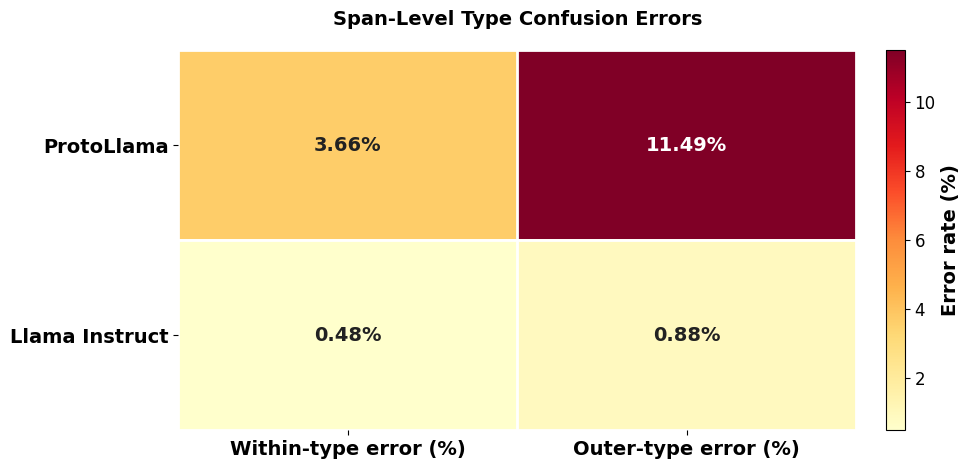

In [16]:
# Report-ready error matrix for 5-way 5-shot comparison
from pathlib import Path

within_error = np.array([0.036572, 0.004846]) * 100
outer_error = np.array([0.114942, 0.0088369]) * 100
model_name = ["ProtoLlama", "Llama Instruct"]

error_matrix = pd.DataFrame(
    {
        "Within-type error (%)": within_error,
        "Outer-type error (%)": outer_error,
    },
    index=model_name,
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(error_matrix, cmap="YlOrRd", aspect="auto")

ax.set_xticks(np.arange(error_matrix.shape[1]))
ax.set_yticks(np.arange(error_matrix.shape[0]))
ax.set_xticklabels(error_matrix.columns, fontsize=14, fontweight="bold")
ax.set_yticklabels(error_matrix.index, fontsize=14, fontweight="bold")
ax.set_title("Span-Level Type Confusion Errors", fontsize=14, fontweight="bold", pad=18)

for i in range(error_matrix.shape[0]):
    for j in range(error_matrix.shape[1]):
        value = error_matrix.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}%",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="white" if value > error_matrix.values.max() * 0.55 else "#222222",
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Error rate (%)", fontsize=14, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

ax.spines[:].set_visible(False)
ax.set_xticks(np.arange(error_matrix.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(error_matrix.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/type_confusion_error_matrix.png", dpi=300, bbox_inches="tight")
fig.savefig("figures/type_confusion_error_matrix.pdf", bbox_inches="tight")
plt.show()

In [ ]:
within_error = np.array([0.036572, 0.004846])*100
outer_error = np.array([0.114942, 0.0088369])*100
model_name = ['proto', 'instruct']